<a href="https://colab.research.google.com/github/j-see17/Python-Coding/blob/main/Copy_of_BUMK744_PCA_I_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Principal Component Analysis (PCA) - I**
*BUMK744 Marketing Research and Analytics*

**Learning objectives:**

In this Jupyter Notebook we will start working with **Principal Component Analysis (PCA)**.

The general learning goal is twofold:

1. To understand the intuition behind PCA
2. To become familiar with the PCA functionality in scikit-learn

Contents:

> - [A] Importing
> - [B] Loading the Iris dataset from scikit-learn
> - [C] Descriptive statistics
> - [D] PCA in 2D: intuition
> - [E] PCA in 2D: scikit-learn
> - [F] Refresher: Linear algebra in Python
> - [G] Rotating with PCA
> - [H] Interpreting the principal component scores
> - [I] Properties of the principal component scores

**Note!!**
> - This notebook makes use of several plotting packages and functions available in Python
> - You need to be able to copy-paste and adapt these plotting functions, for example, changing variable names

---
## **[A] Importing**

In this lecture we will import several packages:
- We have worked with the first two packages, **`numpy`** and **`pandas`**
- The third subpackage **`matplotlib.pyplot`** is the default plotting package for Python, which we will import under the alias **`plt`**
- The fourth package **`seaborn`** is a package for statistical data visualization, that we will import under the alias **`sns`**

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # better looking plots

In addition, we will work with **scikit-learn**, a large Python library that contains many different machine learning methods.

Notes:
> - **Important**: The package name of scikit-learn is **`sklearn`**. It is **not** scikit-learn!!
> - Because scikit-learn is a **large library**, it is designed such that you **import smaller parts** of it piece-by-piece, instead of everything at once

---
## **[B] Loading the Iris dataset from scikit-learn**

We will start working with PCA using the **Iris** dataset. This is a small well-known machine learning dataset about 150 flowers that can help us understand and visualize PCA. You can read more about this dataset here: https://en.wikipedia.org/wiki/Iris_flower_data_set

![iris_setosa](https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg/220px-Kosaciec_szczecinkowaty_Iris_setosa.jpg)
![iris_versicolor](https://upload.wikimedia.org/wikipedia/commons/thumb/4/41/Iris_versicolor_3.jpg/220px-Iris_versicolor_3.jpg)
![iris_virginica](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Iris_virginica.jpg/220px-Iris_virginica.jpg)


To load in the Iris dataset, we first load in the `datasets` submodule from `sklearn`:

In [24]:
from sklearn import datasets

From `datasets` we will now load the **Iris** data set using the `load_iris` method:

In [25]:
# Load the dataset into the iris variable
iris = datasets.load_iris()

# From the dataset, extract X, y, and variable labels
X = iris.data
y = iris.target
variable_labels = iris.feature_names

# Create a dataframe for X
X = pd.DataFrame(X, columns=variable_labels)

In [26]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


About the data:
- There are 150 records (rows)
- Each record corresponds to a flower for which the petal's and sepal's length and width (in centimers) is recorded, so we have 4 variables in total

![sepal_petal](https://www.wpclipart.com/plants/diagrams/plant_parts/petal_sepal_label.png)

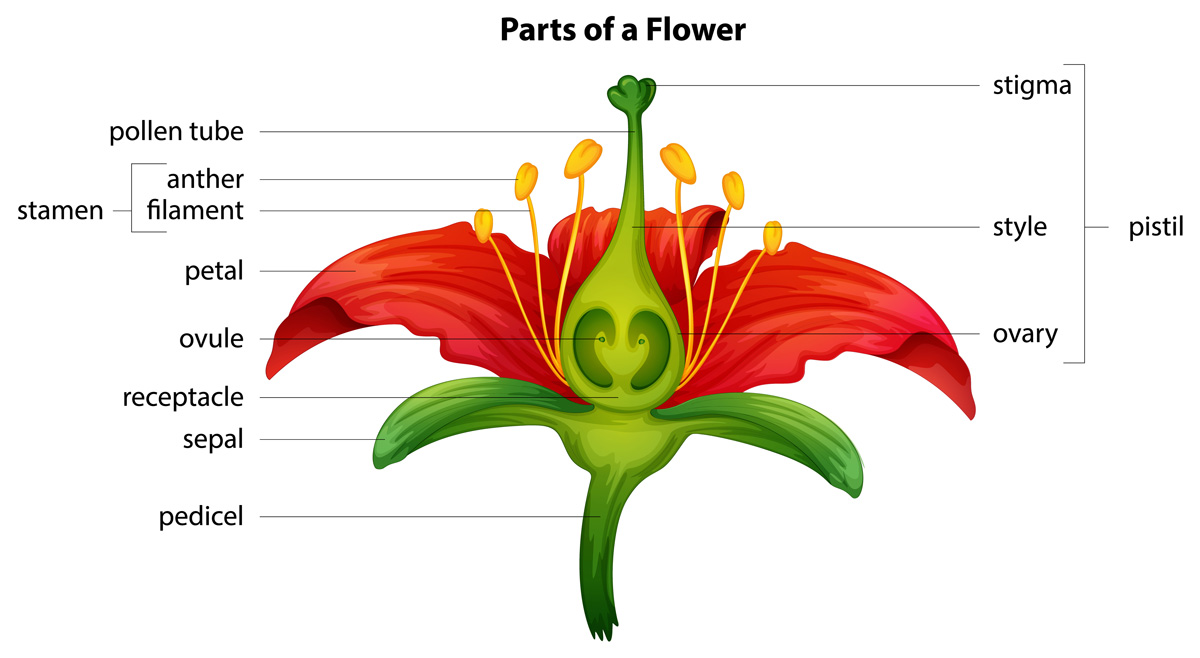

---
## [C] Descriptive statistics

Before applying any statistical method to data, your first step should always be to look at some **descriptive statistics** of the dataset.

The **sample mean** of the data **`X`** can be computed using the **`mean`** method of a pandas DataFrame:

In [27]:
X.mean().round(2)

,0
sepal length (cm),5.84
sepal width (cm),3.06
petal length (cm),3.76
petal width (cm),1.20


**Note**: The **difference in scale** between the variables
- `sepal length` has a mean of approximately 5.84
- `petal width` only has a mean of approximately 1.20

The **sample variance** of the data **`X`** can be computed using the **`var`** method of a pandas DataFrame:

In [28]:
X.var().round(2)

,0
sepal length (cm),0.69
sepal width (cm),0.19
petal length (cm),3.12
petal width (cm),0.58


**Note**: The **difference in variance** between the variables
- `petal length` has a variance of approximately 3.12
- `sepal width` only has a variance of approximately 0.19
- Interesting observations:
 - `sepal length` has the largest mean (5.84) but has a relatively small variance (0.69)
 - On the other hand, `petal length` has the largest variance (3.12) but has a relatively modest mean in comparison (3.75)

Why is it important to look at these variances? Because the **relative magnitude of the variances** is important for PCA.

To learn more about the relations between variables we can compute the **covariance matrix** of the data **`X`** using the **`cov`** method of a pandas DataFrame:

In [29]:
X.cov().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.69,-0.04,1.27,0.52
sepal width (cm),-0.04,0.19,-0.33,-0.12
petal length (cm),1.27,-0.33,3.12,1.30
petal width (cm),0.52,-0.12,1.30,0.58


What do we know about the **covariance matrix** in general:
- The **diagonal elements** correspond to the **variances**
- The **off-diagonal elements** correspond to **covariances**
- For two variables $X$ and $Y$ it holds that: $abs(cov(X, Y)) \leq \max\{ var(X), var(Y) \}$. <br><br>In words, the absolute value of the covariance between $X$ and $Y$ (off-diagonal element) is always smaller than or equal to largest the variance of $X$ and $Y$ (corresponding diagonal element)

**Variances** and **covariances** are not bounded between certain values. For example, a covariance smaller than $-1$ is possible, or a variance larger than $+1$ is possible. This makes it more difficult to directly interpret these values.


Therefore, in general, a **correlation matrix** is easier to interpret than a covariance matrix. To compute a **correlation matrix** using pandas, you can use the **`corr`** method of a pandas DataFrame:

In [30]:
X.corr().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


What do we know about the **correlation matrix** in general:
- The **diagonal elements** are always equal to 1
- The **off-diagonal elements** correspond to **correlations** between variables
- A **correlation is bounded** between $-1$ and $+1$
- The **closer** a correlation between two variables is to $-1$ or $+1$ the **stronger the (linear) relationship** between two variables

**Note**: In the Iris dataset we observe a **very strong correlation** between some of the 4 variables:
> - `petal length` and `petal width` have a correlation of 0.96
> - What does this mean in words? If you know a flower's `petal width` you can use `petal width` to make a **very accurate** guess about that flower's `petal length`. In a way, knowing one variables makes the other more or less **redundant**

On the other hand, some variables have a **small** correlation:
> - `sepal length` and `sepal width` do not seem to be strongly correlated (-0.12)
> - What does this mean in words? If you know a flower's `sepal length`, then that does not provide you with a lot of information about that flower's `sepal width`. In a way, both variables are more or less **independent**

For more insight we can use the **`pairplot`** function from the **`seaborn`** plotting package (which we have imported as **`sns`**).

The **`pairplot`** function creates a **scatterplot matrix** between every variable in the data.
- Each **off-diagonal** subplot corresponds to a scatterplot between two distinct variables
- Each **diagonal** subplot provides a histogram of a single variable

**Note**: Do not use the **`pairplot`** function if you have many different variables (if $P$ is large), the code will be very slow

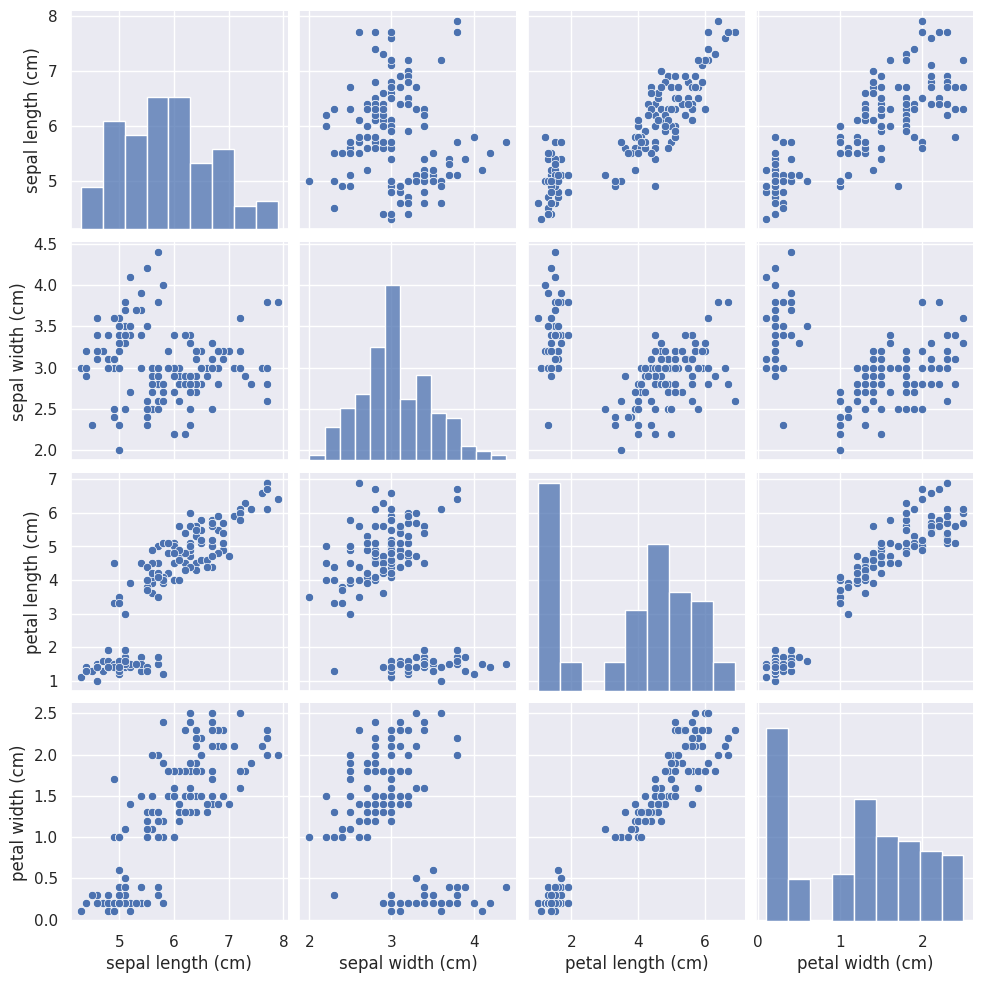

In [31]:
g = sns.pairplot(data=X)

First, consider the scatterplot between **`petal width`** and **`petal length`**:
> - These two variables have a **very strong positive correlation** of about 0.96
> - As a result, the points in their scatterplot are situated **close to a single straight line**

Second, consider the scatterplot between **`sepal width`** and **`sepal length`**:
> - These two variables have a **weak negative correlation** of about -0.11
> - As a result, the points in their scatterplot are spread out and **cannot be accurately captured by a single straight line**

---
## **[D] PCA in 2D: intuition**

The reason that we are so focused on the covariances (and correlations) between the variables in the dataset **`X`** is because that is the information in the data PCA focuses on.

In a nutshell, what PCA achieves:
1. PCA creates a **set of new variables**
2. Each of these new variables is a **linear combination** of the $P$ original variables in the dataset **`X`**
3. These linear combinations describe **directions in the data**
4. The directions are **sorted in descending order by the amount of variance they describe**
 - The first direction describes the most variance
 - The second direction describes the second-most variance
 - The third direction describes the third-most variance
 - ... and so and so forth
5. That is why the directions are also called **principal directions** that describe the **principal components** of the data
6. The original records $\mathbf{x}_i$ can be described (think: transformed) in terms of these **principal components** in place of the $P$ original variables in the dataset **`X`**

Because the **principal components** are sorted, the fundamental idea of PCA follows:
> - We can summarize information about all $P$ original variables in the dataset **`X`**<br>by only considering a **small number** of **principal directions**.

Below we will explore the intuition behind PCA in just two dimensions
- The ideas discussed will carry over to datasets with more variables

Because it is easy to visualize two-dimensional records (2D vectors) we will initially focus on just 2 of the 4 variables in the Iris data set, that relate to length:
> - **`sepal length`** (first variable)
> - **`petal length`** (third variable)

In [32]:
X_only_length = X.loc[:, ['sepal length (cm)', 'petal length (cm)']]
X_only_length

,sepal length (cm),petal length (cm)
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4
...,...,...
145,6.7,5.2
146,6.3,5.0
147,6.5,5.2
148,6.2,5.4


### Scatterplot

We can create a scatterplot for these two variables using the **`scatterplot`** function in **seaborn**:

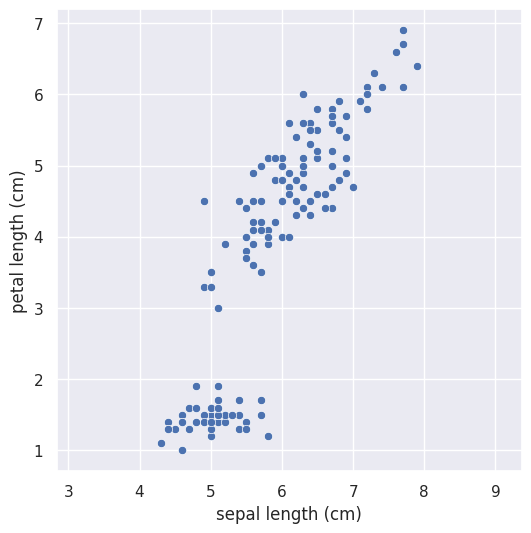

In [33]:
fig = plt.figure(figsize=[6, 6])

#
# NEW CODE - START
#

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

# Scatterplot between sepal length (x) and petal length (y)
g = sns.scatterplot(
    x=X_only_length.loc[:, 'sepal length (cm)'],
    y=X_only_length.loc[:, 'petal length (cm)'],
)

g.axis('equal')

#
# NEW CODE - STOP
#

plt.show()

By looking at this scatterplot we get a few important take-aways:
- Both variables show some variance
- The variability of **`petal length`** (**vertical axis**) is much larger than the variability of  **`sepal length`** (**horizontal axis**)
    - **`petal length`** ranges between approximately 1cm and 7cm
    - **`sepal length`** ranges between approximately 4cm and 8cm
    
We can verify this intuition by looking at the sample variance:

In [34]:
X_only_length.var()

,0
sepal length (cm),0.685694
petal length (cm),3.116278


### Direction of maximal variance

Now consider the question: In which **direction** of the data is the **variance maximal**?
- Think of a direction as a **straight line** through the data
- Clearly, the petal length (y-axis) has a larger variance than the sepal length (x-axis)
- However, a **direction** can be any linear **combination** of the two variables

**Question**: Looking at the scatter plot, can we find a direction in the data for which the variance is larger than for only `petal length` (y-axis) or only `sepal length` (x-axis)?

**Answer**: The **direction** in the data **for which the variance is maximal** will be a **combination** of **`petal length`** and **`sepal length`**
1. Before we formally get to PCA, we can use our **intuition**: try and find this line by drawing it in the scatterplot
2. In this case, the line with maximal variance will have a **positive slope**
3. The slope of this line will **primarily** be influenced by **`petal length`**.<br>Why? **Because it has a larger variance than `sepal length`**<br>This results in a steeper slope, such that the **direction of maximal variance** will be close(r) to the y-axis (vertical line)
4. However, **`sepal length` plays a role as well**.<br>Why? **Because it also has some variance that cannot be explained by `petal length`**.<br>This results in a flatter slope, such that the **direction of maximal variance** will be close(r) to the x-axis (horizontal line)
5. In the end the direction of maximal variance will be a **combination** of both variables.<br>What that combination exactly looks like depends on the **variances** of both variables

This is the idea underlying PCA:
> PCA will find the **coefficients** that describe the direction of maximal variance

---
## **[E] PCA in 2D: scikit-learn**

Before we can use the PCA functionality from **scikit-learn** we need to import it.

The PCA functionality is called **`PCA`** and can be found in the **`decomposition`** subpackage of scikit-learn:

In [35]:
from sklearn.decomposition import PCA

After importing `PCA` we have to **initialize** a **PCA object** by calling the imported **`PCA`** function:
- Note: **By default we do not have to provide arguments to the `PCA` function**

In [36]:
our_1st_PCA = PCA()

### `fit` method

We can find the **principal directions** (also called **principal axes**) for the data matrix by using the **`fit`** method from the PCA object.

An **important remark** regarding the `fit` method:
- The `fit` method automatically **demeans** (centers) the data matrix for you
- If you decide to demean (center) the data before providing it to the PCA object, it will not change your results


In [37]:
our_1st_PCA.fit(X=X_only_length)

PCA()

### `components_` attribute
After calling **`fit`** on our PCA object, we can now access the estimated **principal directions** of the data.

Synonyms for a principal direction are:
- **principal axis**
- **eigenvector**

The PCA object stores the estimated **principal directions** in the **`components_`** attribute
- Note the trailing underscore, the attribute is `components_` and not `components`!


In [38]:
# Store the principal directions in a variable called directions
directions = our_1st_PCA.components_
directions

array([[ 0.39360585,  0.9192793 ],
       [ 0.9192793 , -0.39360585]])

About **`components_`**:
1. It is an $L \times P$ matrix (stored as a numpy array)
 - $L$ is the number of *requested* principal components
 - $P$ is the number of variables (columns) in **`X`**
 - In scikit-learn, $L = P$ by default. In the next notebook we will learn how to change that value
2. The $k$th **row** describes the **direction** corresponding to the $k$th principal component
 - A direction is described by a set of **coefficients** for each of the $P$ variables
3. In PCA the principal **directions are sorted in descending order of explained variance**
 - Variance here corresponds to the variance in the dataset **`X`**
 - The 1st principal component, corresponding to the 1st row in `components_`, explains the most variance in the data
 - The 2nd principal component, corresponding to the 2nd row in `components_`, explains the second-most variance in the data
 - And so on and so forth (if we have more than 2 components)

Using the above, we can store the principal directions in a pandas DataFrame and label the rows and columns:

In [39]:
directions = pd.DataFrame(
    data=our_1st_PCA.components_,
    index=['PC1', 'PC2'],
    columns=X_only_length.columns,
)
directions.round(2)

,sepal length (cm),petal length (cm)
PC1,0.39,0.92
PC2,0.92,-0.39


### `components_` interpretation

How do we interpret the numbers in `components_`?

Let's first focus on the 1st principal direction:
- The 1st row in `components_` gives the **coefficients** of the 1st principal direction
- These coefficients describe the **slope** of the **straight line** in the data that **maximizes variance**
- Each principal direction is described by a **unique** combination of coefficients

Remember:
- Earlier in the notebook, we tried to find this direction using intuition.
- Now with PCA, we actually have the **exact solution** for the 1st principal direction.

In the plot below, we visualize the 1st principal direction using two red arrows:

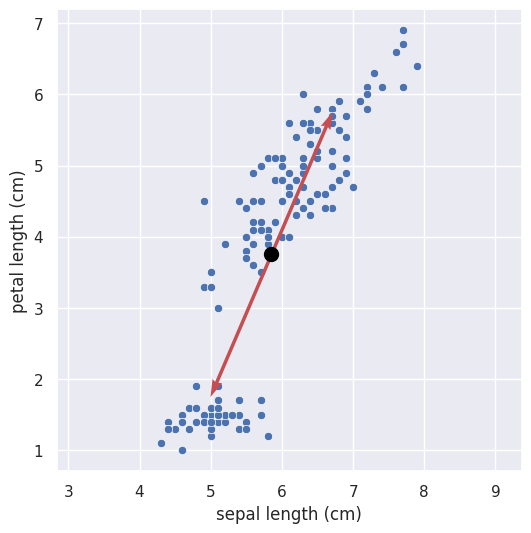

In [40]:
fig = plt.figure(figsize=[6, 6])

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

# Scatterplot between sepal length (x) and petal length (y)
g = sns.scatterplot(
    x=X_only_length.loc[:, 'sepal length (cm)'],
    y=X_only_length.loc[:, 'petal length (cm)'],
)

g.axis('equal')

#
# NEW CODE - START
#

# Add a black dot that corresponds to the mean of the data
plt.scatter(*X_only_length.mean().values, s=100, c='black', zorder=10)

# Draw the 1st principal direction
# - Remember: This corresponds to the maximal variance in the data!
# - Note: You don't have to know how to draw this
plt.quiver(
    *X_only_length.mean().values,
    *directions.iloc[0],
    scale=3,
    color='r'
)
plt.quiver(
    *X_only_length.mean().values,
    *-directions.iloc[0],
    scale=3,
    color='r',
)

#
# NEW CODE - STOP
#

plt.show()

In the same way, we can visualize the 2nd principal direction using two blue arrows:

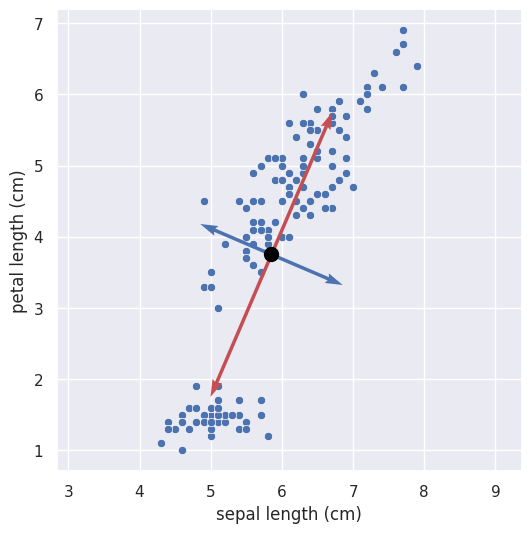

In [41]:
fig = plt.figure(figsize=[6, 6])

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

# Scatterplot between sepal length (x) and petal length (y)
g = sns.scatterplot(
    x=X_only_length.loc[:, 'sepal length (cm)'],
    y=X_only_length.loc[:, 'petal length (cm)'],
)

g.axis('equal')

# Add a black dot that corresponds to the mean of the data
plt.scatter(*X_only_length.mean().values, s=100, c='black', zorder=10)

# Draw the 1st principal direction
# - Remember: This corresponds to the maximal variance in the data!
# - Note: You don't have to know how to draw this
plt.quiver(
    *X_only_length.mean().values,
    *directions.iloc[0],
    scale=3,
    color='r'
)
plt.quiver(
    *X_only_length.mean().values,
    *-directions.iloc[0],
    scale=3,
    color='r',
)

#
# NEW CODE - START
#

# Draw the 2nd principal direction
# - Note: You don't have to know how to draw this
plt.quiver(
    *X_only_length.mean().values,
    *directions.iloc[1],
    scale=6,
    color='b'
)
plt.quiver(
    *X_only_length.mean().values,
    *-directions.iloc[1],
    scale=6,
    color='b',
)

#
# NEW CODE - STOP
#

plt.show()

Note:
- The principal directions are **perpendicular** (they meet at a 90 degree angle)
- Another way to say this is that the two principal directions are **orthogonal**
- This is **not a coincidence**, but **by design of PCA**

In essence, what the output of PCA gives us is a **new way** to look at our data:
- Instead of interpreting the data in terms of **`sepal length`** and **`sepal width`** (the two original variables in the data) we will interpret the data in terms of the 1st principal direction and the 2nd principal direction
- For this we need to perform a **rotation** using linear algebra

## [F] Some linear algebra in Python



Using **linear algebra** we can create a **rotation** by using a **matrix-matrix multiplication**
- To perform a **matrix-matrix multiplication** in Python we use the **`@`** operator
- To **transpose** a **matrix** in Python we use the **`.T`** attribute on the matrix
 - Note: Transposing works on both a numpy array and a pandas DataFrame


Let's try this with a $2 \times 2$ matrix `A`:

In [42]:
A = np.array([
    [1, 2],
    [3, 4]
])
A

array([[1, 2],
       [3, 4]])

The **transpose** of `A` is given by `A.T`:

In [43]:
A.T

array([[1, 3],
       [2, 4]])

The **matrix multiplication** between `A` and `A.T`:

In [44]:
A @ A.T

array([[ 5, 11],
       [11, 25]])

Note: This is **not** the same as the matrix multiplication between `A.T` and `A`, **order matters** when multiplying matrices:

In [45]:
A.T @ A

array([[10, 14],
       [14, 20]])

## [G] Rotating with PCA

### Rotating the principal directions

By **rotating** the principal directions we can have that:
- The 1st principal component becomes the x-axis
- The 2nd principal component becomes the y-axis

To rotate the principal directions using linear algebra we need to multiply them with a matrix, so we need to perform a **matrix-matrix multiplication**:
- The first matrix is the matrix with the **principal directions**: the **`directions`** variable
- The second matrix is the matrix with the **transpose** of the principal directions: the **`directions.T`** variable

So, to perform the rotation we have:

In [46]:
rotated_directions = pd.DataFrame(
    directions.values @ directions.values.T,
    index=['PC1', 'PC2'],
    columns=['X', 'Y'],
)
pd.DataFrame(rotated_directions).round(4)

,X,Y
PC1,1.0,-0.0
PC2,-0.0,1.0


We can now plot these rotated directions using the arrows as before:
- Note, we redefine the origin (the point (0, 0)) as the intersection between the two axes

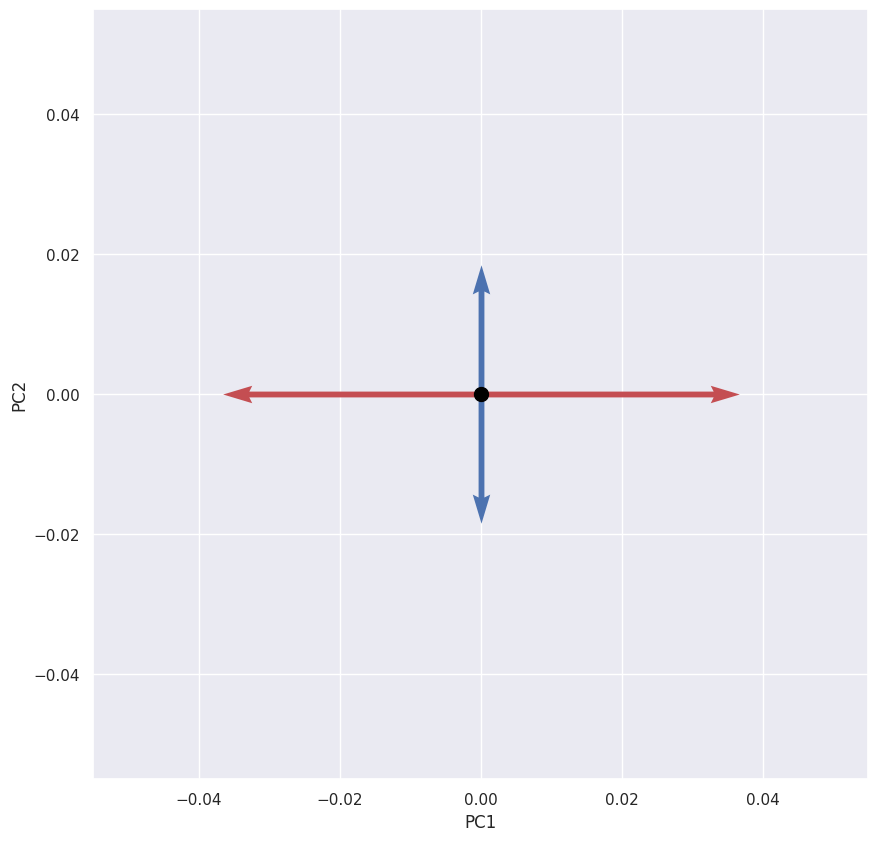

In [47]:
fig = plt.figure(figsize=[10, 10])

plt.xlabel('PC1')
plt.ylabel('PC2')

# Add a black dot that corresponds to the mean of the data
plt.scatter(*[0, 0], s=100, c='black', zorder=10)

# Draw the 1st principal direction
# - Remember: This corresponds to the maximal variance in the data!
# - Note: You don't have to know how to draw this
plt.quiver(
    *[0, 0],
    *rotated_directions.iloc[0],
    scale=3,
    color='r'
)
plt.quiver(
    *[0, 0],
    *-rotated_directions.iloc[0],
    scale=3,
    color='r',
)

# Draw the 2nd principal direction
# - Note: You don't have to know how to draw this
plt.quiver(
    *[0, 0],
    *rotated_directions.iloc[1],
    scale=6,
    color='b'
)
plt.quiver(
    *[0, 0],
    *-rotated_directions.iloc[1],
    scale=6,
    color='b',
)

plt.show()

### Rotating the data into principal component scores

The next step is to rotate the data, such that the data is not described in terms of the original $P$ variables, but in terms of scores on the $L$ principal components.

This involves two steps:
1. **Demeaning the data**, as we want the data to be centered around the origin (0, 0)<br>Why? Because:<br> i) it makes intuitive sense to start axes at the origin<br> ii) this is what the `PCA` object in `sklearn` also does
2. Performing a matrix-matrix multiplication between the **demeaned data matrix** and the **transposed principal directions**

In [51]:
demeaned_X_only_length = X_only_length - X_only_length.mean()
pc_scores = pd.DataFrame(
    demeaned_X_only_length @ directions.T
)

pc_scores.round(4)

,PC1,PC2
0,-2.4602,0.2448
1,-2.5390,0.0609
2,-2.7096,-0.0836
3,-2.5651,-0.2542
4,-2.4996,0.1529
...,...,...
145,1.6628,0.2199
146,1.3215,-0.0691
147,1.5841,0.0361
148,1.6498,-0.3184


The 10th row (for example) of `rotated_X_only_length` now contains the scores of the 11th observation on the two principal components:

In [52]:
pc_scores.iloc[10]

,10
PC1,-2.250231
PC2,0.481215


Which is very different from the values of the 11th observation for the two variables:

In [53]:
X_only_length.iloc[10]

,10
sepal length (cm),5.4
petal length (cm),1.5


We can plot the `rotated_X_only_length` values:

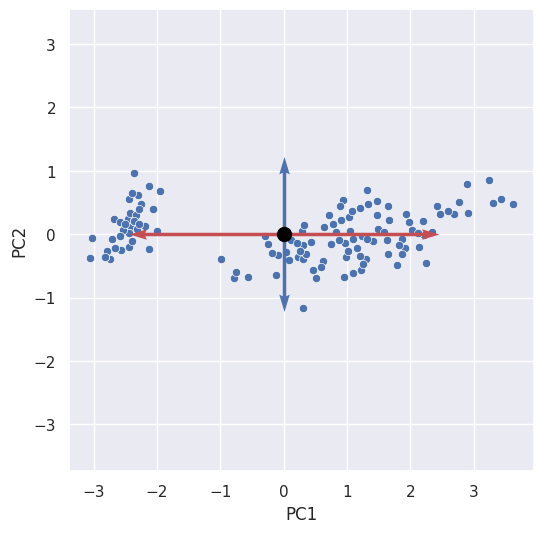

In [54]:
fig = plt.figure(figsize=[6, 6])

plt.xlabel('PC1')
plt.ylabel('PC2')

# Scatterplot between sepal length (x) and petal length (y)
g = sns.scatterplot(
    x=pc_scores.loc[:, 'PC1'],
    y=pc_scores.loc[:, 'PC2'],
)
g.axis('equal')

# Add a black dot that corresponds to the mean of the data
plt.scatter(*[0, 0], s=100, c='black', zorder=10)

# Draw the 1st principal direction
# - Remember: This corresponds to the maximal variance in the data!
# - Note: You don't have to know how to draw this
plt.quiver(
    *[0, 0],
    *rotated_directions.iloc[0],
    scale=3,
    color='r'
)
plt.quiver(
    *[0, 0],
    *-rotated_directions.iloc[0],
    scale=3,
    color='r',
)

# Draw the 2nd principal direction
# - Note: You don't have to know how to draw this
plt.quiver(
    *[0, 0],
    *rotated_directions.iloc[1],
    scale=6,
    color='b'
)
plt.quiver(
    *[0, 0],
    *-rotated_directions.iloc[1],
    scale=6,
    color='b',
)

plt.show()

Compare that against the plot with petal length and sepal length on the axes:

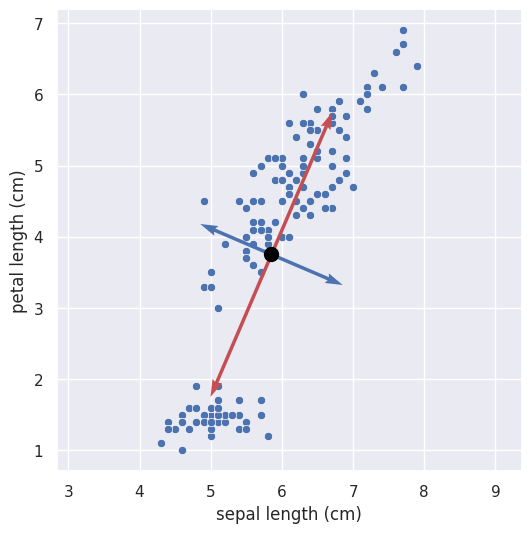

In [55]:
fig = plt.figure(figsize=[6, 6])

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

# Scatterplot between sepal length (x) and petal length (y)
g = sns.scatterplot(
    x=X_only_length.loc[:, 'sepal length (cm)'],
    y=X_only_length.loc[:, 'petal length (cm)'],
)

g.axis('equal')

# Add a black dot that corresponds to the mean of the data
plt.scatter(*X_only_length.mean().values, s=100, c='black', zorder=10)

# Draw the 1st principal direction
# - Remember: This corresponds to the maximal variance in the data!
# - Note: You don't have to know how to draw this
plt.quiver(
    *X_only_length.mean().values,
    *directions.iloc[0],
    scale=3,
    color='r'
)
plt.quiver(
    *X_only_length.mean().values,
    *-directions.iloc[0],
    scale=3,
    color='r',
)

#
# NEW CODE - START
#

# Draw the 2nd principal direction
# - Note: You don't have to know how to draw this
plt.quiver(
    *X_only_length.mean().values,
    *directions.iloc[1],
    scale=6,
    color='b'
)
plt.quiver(
    *X_only_length.mean().values,
    *-directions.iloc[1],
    scale=6,
    color='b',
)

#
# NEW CODE - STOP
#

plt.show()

Note: The **data did not change**
- Instead, we **rotated the data** into a new **coordinate system**
- This new coordinate system is described by the **principal directions**

Instead of manually demeaning the data and performing the matrix multiplication, we can also use the **`transform`** method of the PCA object to rotate the data into principal component scores:

In [56]:
rotated_using_transform_method = pd.DataFrame(
    our_1st_PCA.transform(X_only_length),
    columns=['PC1', 'PC2'],
)
rotated_using_transform_method

,PC1,PC2
0,-2.460241,0.244792
1,-2.538962,0.060936
2,-2.709611,-0.083559
3,-2.565116,-0.254209
4,-2.499602,0.152864
...,...,...
145,1.662790,0.219936
146,1.321492,-0.069054
147,1.584069,0.036080
148,1.649843,-0.318425


We can verify that this is the same as our own transformation:

In [57]:
np.allclose(rotated_using_transform_method, pc_scores)

True

## [H] Interpreting the principal component scores

The next step is to provide an interpretation to the principal component scores. For example:

> **What does it mean if an observation has a high PC1 score?**

We will rephrase this question slightly:

> **Question**: When do we **expect** an observation to have a large positive PC1 score?

To answer this question, we first need to examine the **direction** corresponding to PC1:

In [58]:
directions.loc['PC1']

,PC1
sepal length (cm),0.393606
petal length (cm),0.919279


Note that both variables **positively** contribute to PC1.

We **expect** an observation to have a large positive PC1 score if:
- The value corresponding to **`petal length`** is **positive**<br>**and**
- The value corresponding to **`sepal length`** is **positive**

**Question**: What does a positive value mean for these variables?


Remember that we have **centered** our data:
- Positive values correspond to **above average** values

This allows us to provide a **more intuitive** interpretation.

Restating the above, we **expect** an observation to have a large positive PC1 score if:
- The value corresponding to **`petal length`** is **above average**
- The value corresponding to **`sepal length`** is **above average**

Also, because the coefficient for **`petal length`** is larger (0.919279) than the coefficient for **`sepal length`** (0.393606), intuitively petal length will have a **larger influence** on the score for PC1.
- It is **more likely** that an observation with a large PC1 score has a large **`petal length`** than a large **`sepal length`**

Let's verify this intuition by creating a scatterplot of the PC1 and PC2 scores.

We have done something similar above, but now we will add **index labels** for each observation to the plot as well:

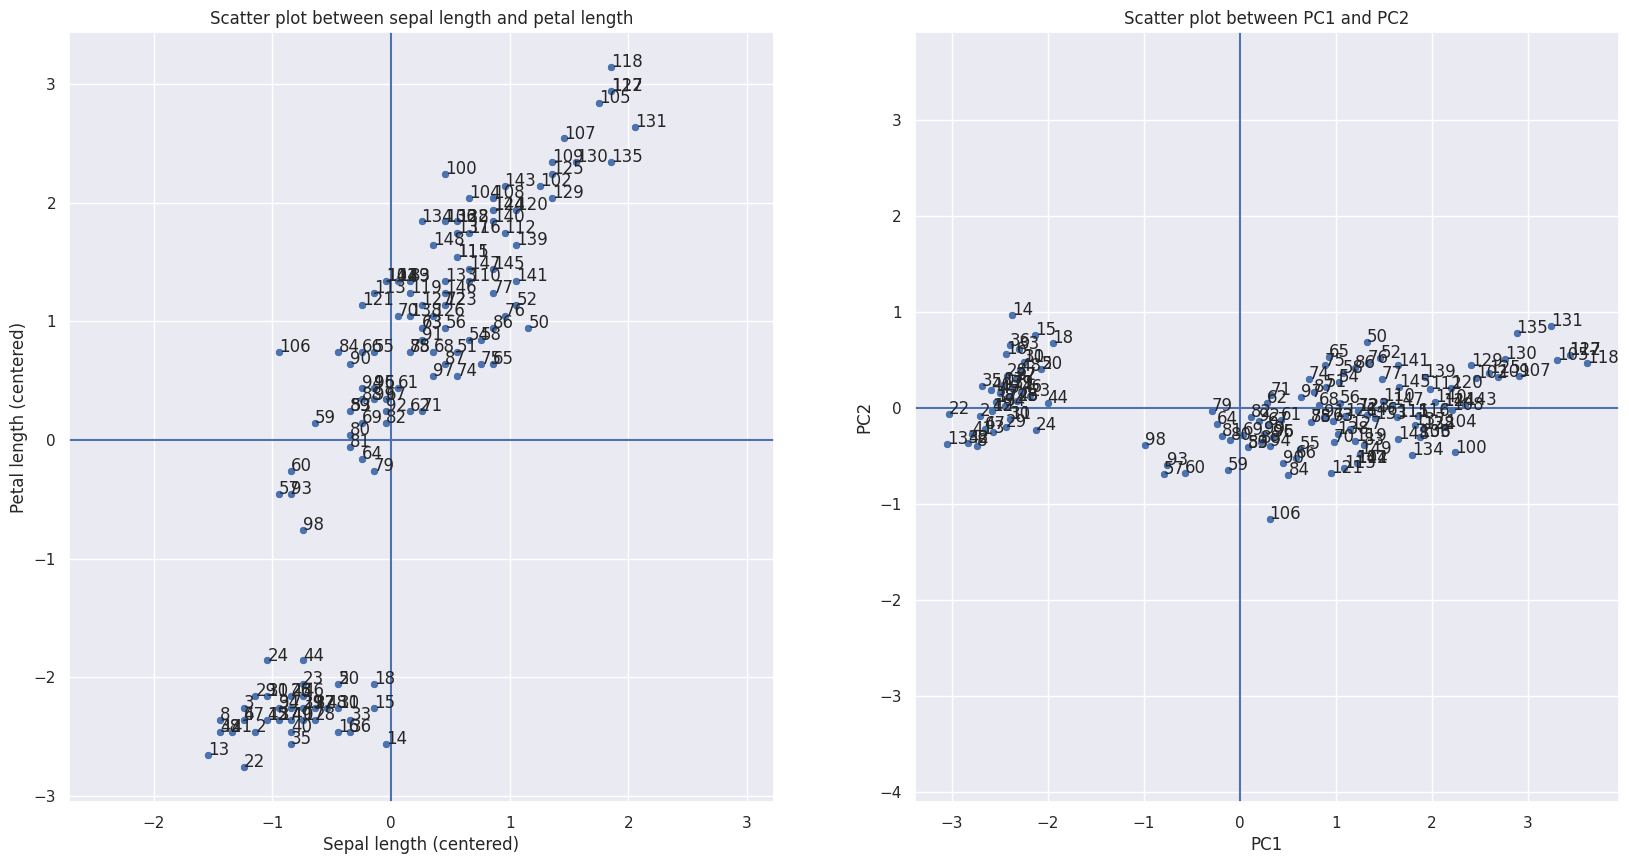

In [59]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=[20, 10])

# Scatterplot between petal length (horizontal) and sepal length (vertical)
ax[0].set_title('Scatter plot between sepal length and petal length')
ax[0].set_xlabel('Sepal length (centered)')
ax[0].set_ylabel('Petal length (centered)')

ax[0].axvline(0)
ax[0].axhline(0)

ax[0] = sns.scatterplot(
    x=demeaned_X_only_length.loc[:, 'sepal length (cm)'],
    y=demeaned_X_only_length.loc[:, 'petal length (cm)'],
    ax=ax[0],
)
ax[0].axis('equal')

# Add index label for each observation
for row_idx, (row_x, row_y) in demeaned_X_only_length.iterrows():
    ax[0].text(row_x, row_y, row_idx)

# Scatterplot between PC1 (horizontal) and PC2 (vertical)
plt.title('Scatter plot between PC1 and PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')

ax[1].axvline(0)
ax[1].axhline(0)

ax[1] = sns.scatterplot(
    x=pc_scores.loc[:, 'PC1'],
    y=pc_scores.loc[:, 'PC2'],
    ax=ax[1],
)
ax[1].axis('equal')

# Add index label for each observation
for row_idx, (row_x, row_y) in pc_scores.iterrows():
    ax[1].text(row_x, row_y, row_idx)

plt.show()

From the two plot it follows that:
- Observations that have an **above average** `sepal length` and `petal length` (for example: observations 118, 122, 105, 131) also have a relatively **large positive** PC1 score

- Observations that have a **below average** `sepal length` and `petal length` (for example: observations 13, 22) also have a relatively **large negative** PC1 score

In other words, if we want to **describe** PC1, we could state that it measures the **length** of a plant in both the sepal and petal dimension, with the caveat that petal length has a larger influence on this score (in other words, it does not represent just the unweighted combination  of sepal and petal length). In a way, PC1 summarizes the **length** information of the plant

---

We could ask a similar question for PC2:

> **Question**: When do we **expect** an observation to have a high PC2 score?

Examining the **direction** corresponding to PC2:

In [61]:
directions.loc['PC2']

,PC2
sepal length (cm),0.919279
petal length (cm),-0.393606


Note that **`sepal length`** has a **negative** contribution to PC2, while **`petal length`** has a **positive** contribution to PC2.

We **expect** an observation to have a large positive PC2 score if:
- The value corresponding to `petal length` is **above average** (positive)<br>**and**
- The value corresponding to `sepal length` is **below average** (negative)

Also, because the coefficient for sepal length is larger in an absolute sense (-0.919279) than the coefficient for petal length (0.393606), intuitively sepal length will have a **larger influence** on the score for PC2.

We can again confirm this intuition by examining the scatter plots above.

## [I] Properties of the principal component scores

The principal component scores are constructed such that they have a number of convenient properties:

> Principal component scores are **centered** (have zero mean)

In [63]:
pc_scores.mean().round(4)

,0
PC1,-0.0
PC2,-0.0


> Principal component scores are **sorted in descending order of variance**

In [64]:
pc_scores.var()

,0
PC1,3.661899
PC2,0.140073


> Principal component scores are **uncorrelated**
> - By design, they are **efficient** in the sense that PC1 does not contain any information about PC2
> - There is **no redundancy** between principal components

In [66]:
pc_scores.cov().round(4)

,PC1,PC2
PC1,3.6619,0.0000
PC2,0.0000,0.1401


- If $L = P$ (we will get to this later), principal component scores **capture all the variation** in the two length variables
 - That is, no information is lost if $L = P$. Remember: **We are not changing the data, just rotating it**
 - Note: This only holds if we keep **all** principal components

In [67]:
np.sum(X_only_length.var())

np.float64(3.8019713646532445)

In [68]:
np.sum(pc_scores.var())

np.float64(3.8019713646532463)

In [70]:
assert np.isclose(np.sum(X_only_length.var()), np.sum(pc_scores.var()))

# Summary

**List of learning objectives**
> General
> - Know how to import data from `sklearn.datasets`
> - Know which descriptive statistics to focus on (when applying PCA)
> - Know the properties of a covariance vs. a correlation
> - Know what it implicitly means when two variables have a very strong correlation (close to -1 or +1) or a very weak correlation (close to 0)
> - The intuition behind PCA in a simple two-dimensional case
> - Know how to make a scatterplot matrix and a scatterplot
> - Know what the direction of maximal variance means intuitively

> `PCA` in `sklearn`
> - Know how to create a `PCA` object
> - Know how to find the principal directions using the `fit` method from the `PCA` object
> - Know how to extract the principal directions from the `PCA` object
> - Know how to interpret the principal directions
> - Understand what happens when we rotate the principal directions
> - Understand that if we rotate the data we get principal component scores
> - Know how to get principal component scores using the `transform` method from the `PCA` object
> - Know how to interpret the principal component scores
> - Know the properties of the principal component scores

To wrap-up:

In this notebook we have made a start with PCA. The focus was on:
- Building intuition
- Using scikit-learn to find the PCA solution
- Interpretation of the principal directions and principal component scores

In the next notebook we will continue with PCA and make it more applied:
- Use PCA to effectively summarize data into a small number of principal components
- Provide an interpretation for the principal directions in terms of the original variables
- More visualization of the data in the principal component coordinate system